# 1. Train — original CRM data (`data/crm/`)

Same steps as `python -m src.train`, one cell per step, using the functions in `src/train.py`.
Models are saved to `reports/crm/final/models/` for `2_evaluate.ipynb` and `3_predict.ipynb`. No test row is scored here.

Kernel: the project environment `.venv-crm` (Python 3.12).

In [1]:
from pathlib import Path
import sys

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "train.py").is_file())
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import pandas as pd
from src import train
from src.data.crm import CRM_DIR


## Settings

In [2]:
DATA_DIR = CRM_DIR   # real Maven CRM tables
QUICK = False            # True: tiny budgets, smoke test only (writes a *smoke* folder)
OUTPUT = train.default_output(DATA_DIR, QUICK)
print("Data:  ", DATA_DIR)
print("Output:", OUTPUT)

Data:   /Users/thaiphan/sources/miu/cs582-project/data/crm
Output: /Users/thaiphan/sources/miu/cs582-project/reports/crm/final


## 1. Load, validate and split the data

Joins the four CRM tables, builds the 18 pre-close features and splits closed deals by engagement date.
Training and validation keep only deals whose outcome was known before the next period.

In [3]:
out, manifest, dataset, split = train.start(OUTPUT, quick=QUICK, data_dir=DATA_DIR)
report = dataset.report
pd.Series({
    "closed deals (labeled)": report["rows"],
    "won": report["positives"],
    "lost": report["negatives"],
    "open deals": report["open_rows"],
    "scorable Engaging deals": report["scorable_open_rows"],
    "scorable deals missing an account": report["scorable_missing_account"],
    "features": len(dataset.feature_columns),
})

closed deals (labeled)               6711
won                                  4238
lost                                 2473
open deals                           2089
scorable Engaging deals              1589
scorable deals missing an account    1088
features                               18
dtype: int64

In [4]:
pd.DataFrame(manifest["split"], index=["value"]).T

,value
method,engagement date groups + outcome availability ...
validation_start,2017-07-15
test_start,2017-09-18
train_rows,2975
validation_rows,583
test_rows,1361
purged_rows,1792
train_win_rate,0.646387
validation_win_rate,0.607204
test_win_rate,0.600294


## 2. Fit the five models

Each cell fits one model on the training rows, picks its class threshold on validation (macro-F1)
and shows its validation metrics.

In [5]:
fitted = {}
COLUMNS = ["model", "roc_auc", "accuracy", "precision", "recall", "f1", "brier", "threshold"]

def show(name):
    return pd.DataFrame([fitted[name][2]])[COLUMNS].round(4)

fitted["dummy_prior"] = train.fit_one("dummy_prior", dataset, split, quick=QUICK)
show("dummy_prior")

,model,roc_auc,accuracy,precision,recall,f1,brier,threshold
0,dummy_prior,0.5,0.6072,0.6072,1.0,0.7556,0.24,0.5


In [6]:
fitted["logistic_regression"] = train.fit_one("logistic_regression", dataset, split, quick=QUICK)
show("logistic_regression")

,model,roc_auc,accuracy,precision,recall,f1,brier,threshold
0,logistic_regression,0.563,0.5609,0.6503,0.5989,0.6235,0.2514,0.48


In [7]:
fitted["random_forest"] = train.fit_one("random_forest", dataset, split, quick=QUICK)
show("random_forest")

,model,roc_auc,accuracy,precision,recall,f1,brier,threshold
0,random_forest,0.54,0.5592,0.6351,0.6441,0.6396,0.2426,0.52


In [8]:
fitted["mlp"] = train.fit_one("mlp", dataset, split, quick=QUICK)
show("mlp")

,model,roc_auc,accuracy,precision,recall,f1,brier,threshold
0,mlp,0.5286,0.5523,0.634,0.6215,0.6277,0.2911,0.46


In [9]:
fitted["tabnet"] = train.fit_one("tabnet", dataset, split, quick=QUICK)
show("tabnet")


Early stopping occurred at epoch 41 with best_epoch = 29 and best_validation_auc = 0.51515


/Users/thaiphan/sources/miu/cs582-project/.venv-crm/lib/python3.12/site-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


,model,roc_auc,accuracy,precision,recall,f1,brier,threshold
0,tabnet,0.5151,0.5386,0.6158,0.6384,0.6269,0.2419,0.58


### Learning curves of the neural models

Early stopping keeps the epoch with the best validation ROC-AUC (dashed line).

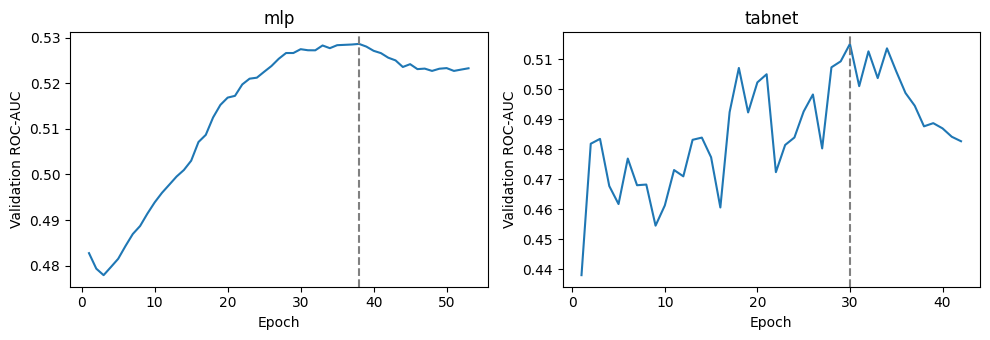

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
for ax, name in zip(axes, ["mlp", "tabnet"]):
    model = fitted[name][0]
    ax.plot(range(1, len(model.history["validation_auc"]) + 1), model.history["validation_auc"])
    ax.axvline(model.settings["best_epoch"], ls="--", color="gray")
    ax.set(title=name, xlabel="Epoch", ylabel="Validation ROC-AUC")
plt.tight_layout()

## 3. Compare on validation, select, calibrate and save

The model with the highest validation ROC-AUC is selected (ties: lower Brier, then name).
A sigmoid calibration is fitted on validation around the frozen selected model.

In [11]:
pd.DataFrame([f[2] for f in fitted.values()])[COLUMNS].sort_values("roc_auc", ascending=False).round(4)

,model,roc_auc,accuracy,precision,recall,f1,brier,threshold
1,logistic_regression,0.5630,0.5609,0.6503,0.5989,0.6235,0.2514,0.48
2,random_forest,0.5400,0.5592,0.6351,0.6441,0.6396,0.2426,0.52
3,mlp,0.5286,0.5523,0.6340,0.6215,0.6277,0.2911,0.46
4,tabnet,0.5151,0.5386,0.6158,0.6384,0.6269,0.2419,0.58
0,dummy_prior,0.5000,0.6072,0.6072,1.0000,0.7556,0.2400,0.50


In [12]:
trained = train.finish(out, manifest, dataset, split, fitted)
print("Selected:", trained.selected)
print("Raw threshold:", trained.thresholds[trained.selected], "-> calibrated:", round(trained.decision_threshold, 4))
print("Calibration slope / intercept:", round(trained.calibrated.slope, 4), round(trained.calibrated.intercept, 4))
sorted(p.name for p in out.models.iterdir())

TRAINED: selected=logistic_regression; models saved in /Users/thaiphan/sources/miu/cs582-project/reports/crm/final/models
Selected: logistic_regression
Raw threshold: 0.48 -> calibrated: 0.6044
Calibration slope / intercept: 0.8269 0.4898


['explanation_reference.json',
 'model_bundle.joblib',
 'model_training.json',
 'trained_models.joblib']

Next: `2_evaluate.ipynb` for test metrics, then `3_predict.ipynb` for scores.